# Week 9: Decision Trees & Ensemble Methods

**Goal:** Implement CART from scratch in MiniLearn.  Apply sklearn Decision Tree, Random Forest, and AdaBoost for empirical comparison.  Discuss overfitting and the benefit of ensembles.

**Deliverable:** `minilearn/classifiers.py` (DecisionTree complete) + this notebook.

---
## Checklist
- [ ] `DecisionTree` (CART) in MiniLearn — Gini splits, max_depth control
- [ ] sklearn DecisionTree for comparison
- [ ] sklearn RandomForest — effect of n_estimators
- [ ] sklearn AdaBoost
- [ ] Tree visualization
- [ ] Overfitting analysis: train vs test accuracy vs max_depth

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.classifiers import DecisionTree
from minilearn.metrics import accuracy, f1_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

EMOTION_MAP = {
    1: 'neutral', 2: 'calm',    3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful', 7: 'disgust',  8: 'surprised'
}
emotion_labels = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP)]

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


def plot_confusion(cm, title, ax, labels):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)


# Load Week-5 preprocessed arrays
X_train = np.load(os.path.join(OUTPUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUTPUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUTPUT_DIR, 'y_train.npy')).astype(int)
y_test  = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy')).astype(int)

feature_names = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'feature_names.csv'), header=None)[0].tolist()

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Features: {len(feature_names)}   Classes: {np.unique(y_train)}')

X_train : (1956, 112)   X_test : (496, 112)
Features: 112   Classes: [1 2 3 4 5 6 7 8]


## 1. MiniLearn DecisionTree (CART)

depth=1  ML train=0.270 test=0.248  |  SK train=0.270 test=0.248
depth=2  ML train=0.307 test=0.286  |  SK train=0.307 test=0.286
depth=3  ML train=0.365 test=0.312  |  SK train=0.365 test=0.312
depth=4  ML train=0.420 test=0.369  |  SK train=0.420 test=0.369
depth=5  ML train=0.469 test=0.389  |  SK train=0.469 test=0.395
depth=6  ML train=0.522 test=0.403  |  SK train=0.522 test=0.395
depth=7  ML train=0.592 test=0.395  |  SK train=0.592 test=0.385
depth=8  ML train=0.673 test=0.395  |  SK train=0.674 test=0.389


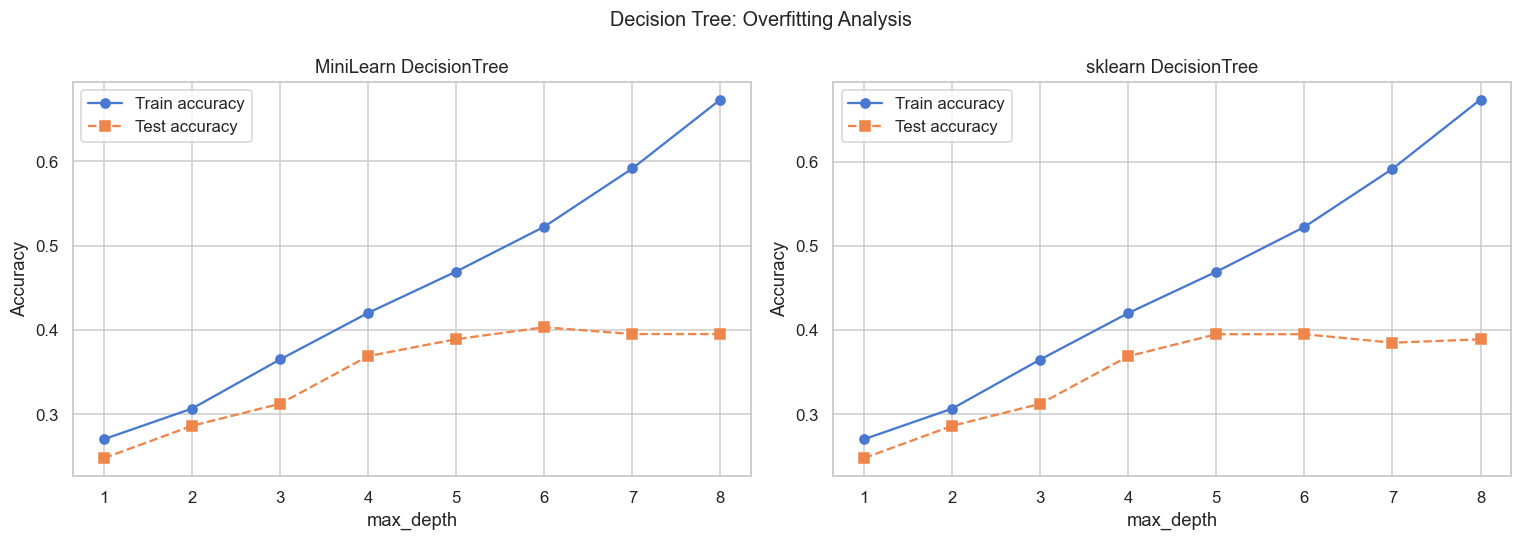


Best MiniLearn depth (test acc): 6


In [2]:
# MiniLearn CART does exhaustive search over all features × thresholds,
# so we cap max_depth at 8 to keep runtime reasonable.
depths = list(range(1, 9))
ml_train_accs, ml_test_accs = [], []
sk_train_accs, sk_test_accs = [], []

for d in depths:
    # MiniLearn
    ml_dt = DecisionTree(max_depth=d, criterion='gini')
    ml_dt.fit(X_train, y_train)
    ml_train_accs.append(accuracy(y_train, ml_dt.predict(X_train)))
    ml_test_accs.append(accuracy(y_test,  ml_dt.predict(X_test)))

    # sklearn (for reference at same depths)
    sk_dt = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=42)
    sk_dt.fit(X_train, y_train)
    sk_train_accs.append(accuracy(y_train, sk_dt.predict(X_train)))
    sk_test_accs.append(accuracy(y_test,  sk_dt.predict(X_test)))

    print(f'depth={d}  ML train={ml_train_accs[-1]:.3f} test={ml_test_accs[-1]:.3f}'
          f'  |  SK train={sk_train_accs[-1]:.3f} test={sk_test_accs[-1]:.3f}')

# ── Overfitting analysis plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tr, te, title) in zip(axes, [
    (ml_train_accs, ml_test_accs, 'MiniLearn DecisionTree'),
    (sk_train_accs, sk_test_accs, 'sklearn DecisionTree'),
]):
    ax.plot(depths, tr, 'o-',  label='Train accuracy')
    ax.plot(depths, te, 's--', label='Test accuracy')
    ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.set_xticks(depths); ax.legend()

plt.suptitle('Decision Tree: Overfitting Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dt_depth_sweep.png'), bbox_inches='tight')
plt.show()

best_depth_ml = depths[int(np.argmax(ml_test_accs))]
print(f'\nBest MiniLearn depth (test acc): {best_depth_ml}')

## 2. sklearn Decision Tree — Visualization

sklearn DT (depth=4)  accuracy : 0.3690
sklearn DT (depth=4)  macro F1 : 0.3032


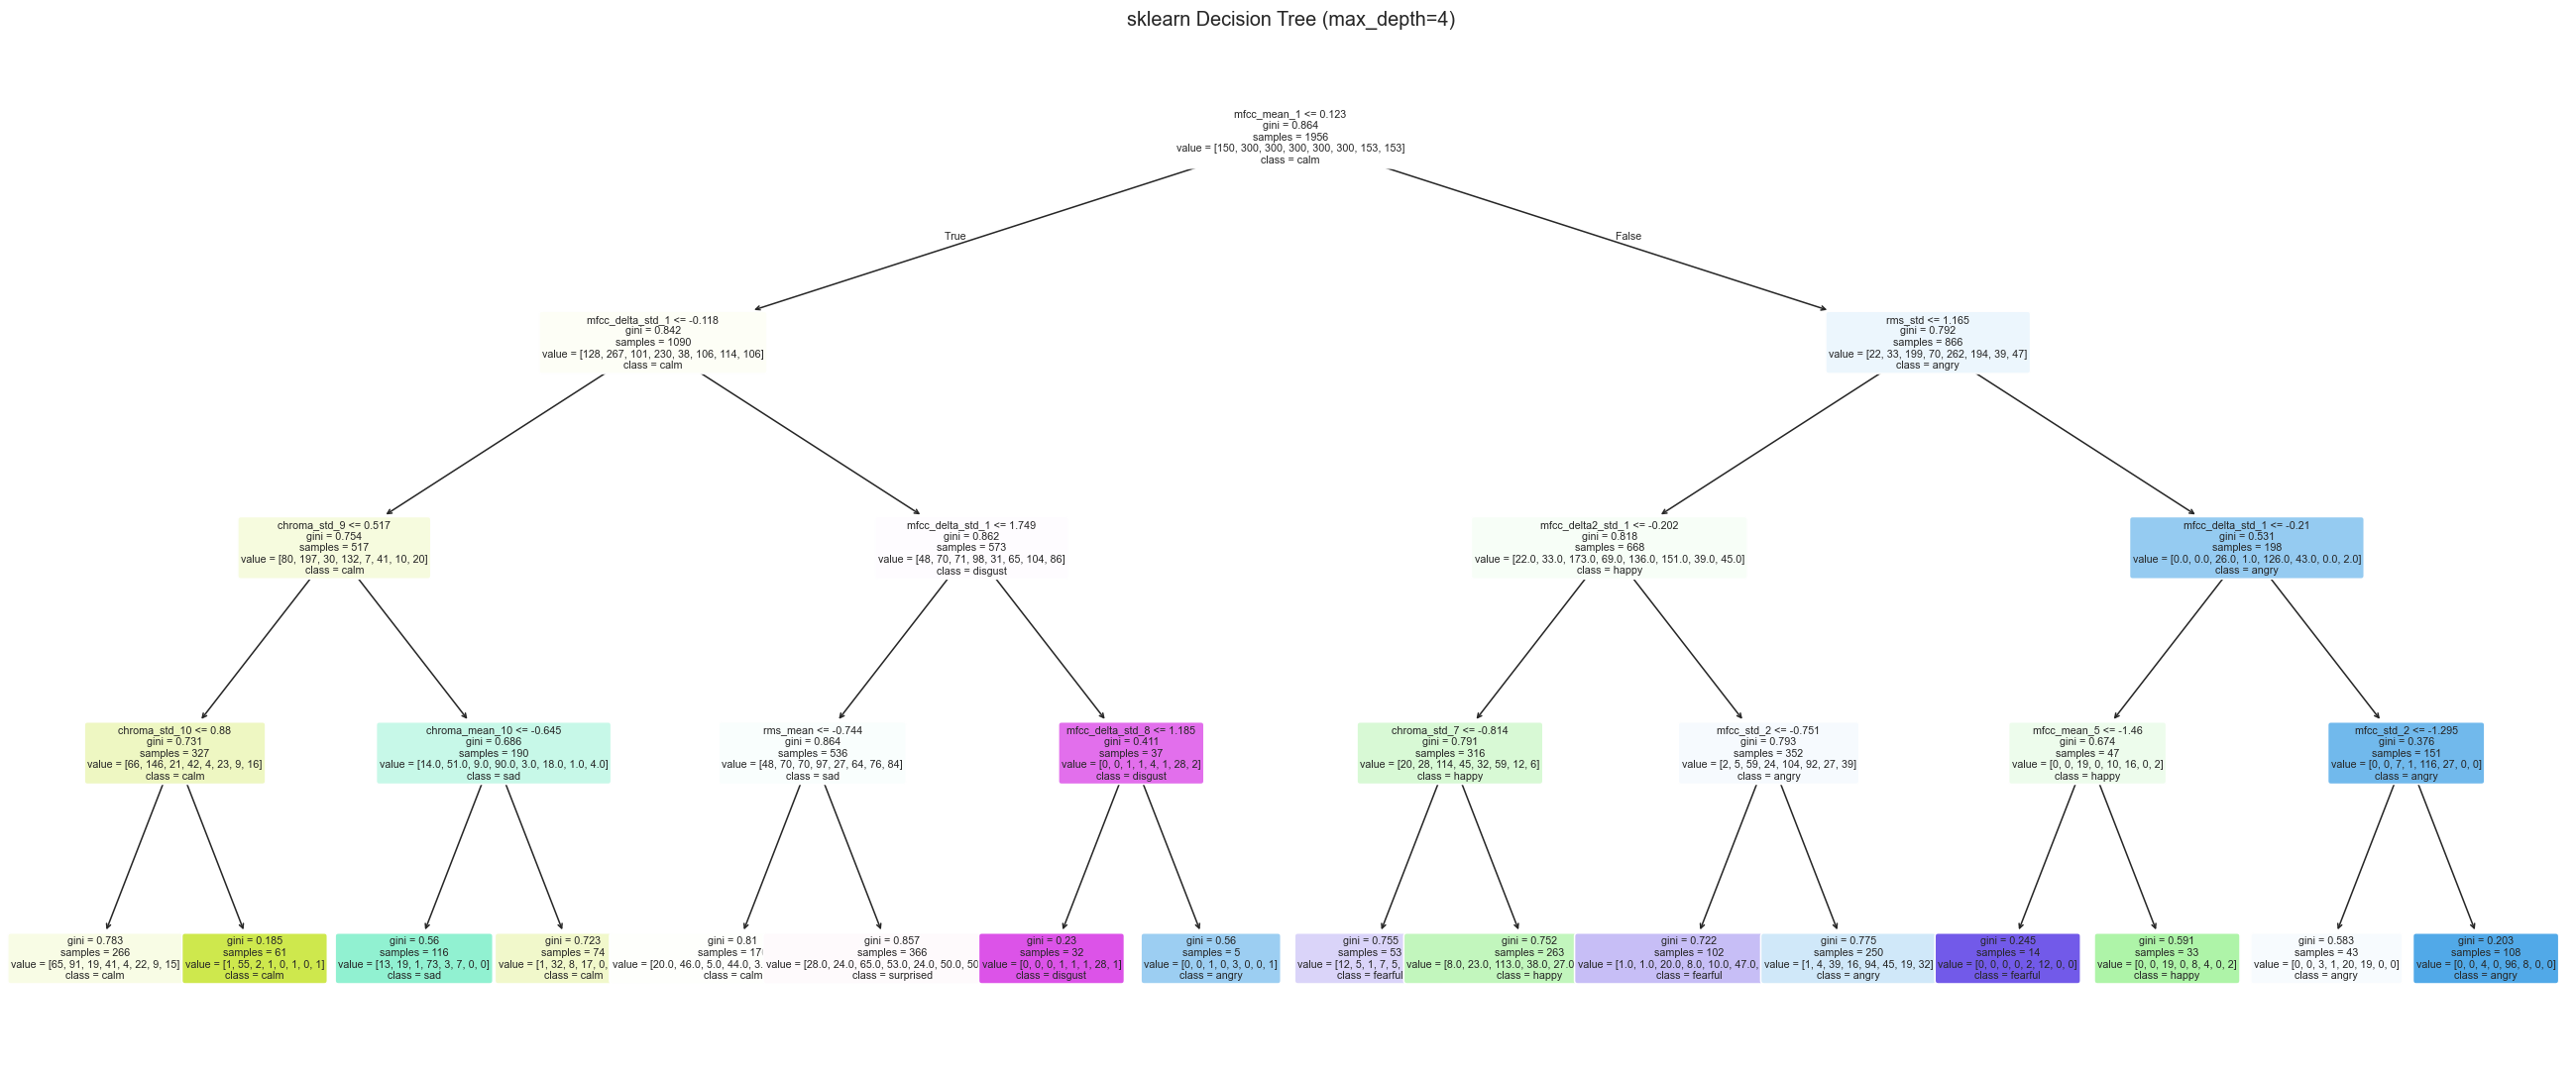

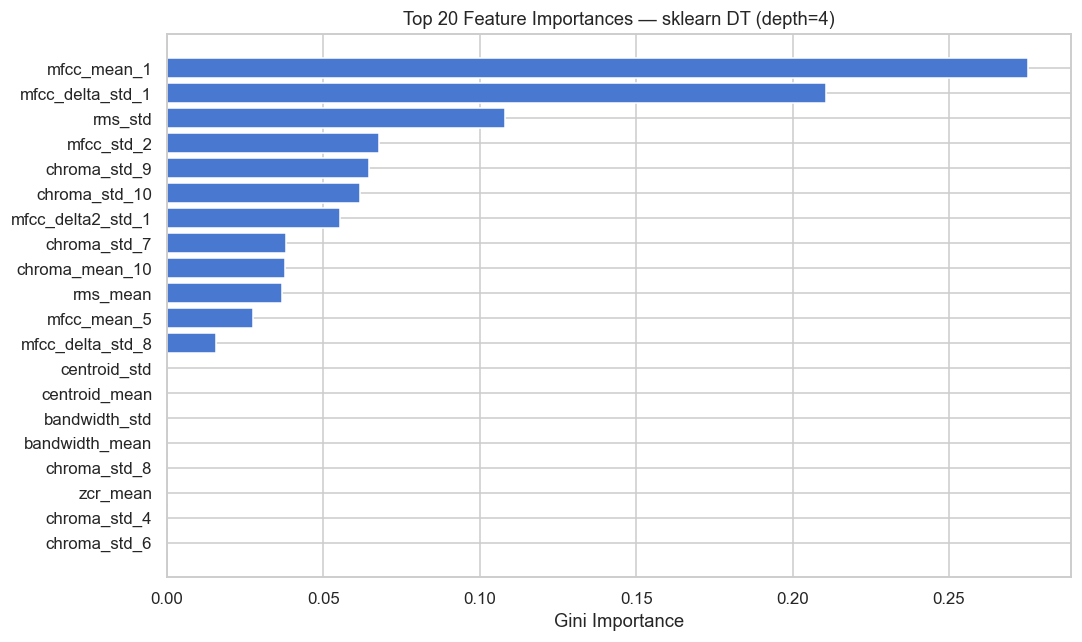

In [3]:
# ── Fit sklearn tree at depth 4 — shallow enough to visualize clearly ────────
sk_dt_vis = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
sk_dt_vis.fit(X_train, y_train)
y_pred_sk_dt = sk_dt_vis.predict(X_test)

print(f'sklearn DT (depth=4)  accuracy : {accuracy(y_test, y_pred_sk_dt):.4f}')
print(f'sklearn DT (depth=4)  macro F1 : {f1_score(y_test, y_pred_sk_dt, average="macro"):.4f}')

# ── Tree visualization ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    sk_dt_vis,
    feature_names=feature_names,
    class_names=emotion_labels,
    filled=True, rounded=True, fontsize=7, ax=ax,
    impurity=True, proportion=False
)
ax.set_title('sklearn Decision Tree (max_depth=4)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dt_tree_viz.png'), bbox_inches='tight', dpi=150)
plt.show()

# ── Feature importances (top 20) ─────────────────────────────────────────────
importances = sk_dt_vis.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]
top_names   = [feature_names[i] for i in top_idx]
top_vals    = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_names[::-1], top_vals[::-1])
ax.set_xlabel('Gini Importance')
ax.set_title('Top 20 Feature Importances — sklearn DT (depth=4)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dt_feature_importances.png'), bbox_inches='tight')
plt.show()

## 3. Random Forest

n_estimators=10    train=0.9939  test=0.4637
n_estimators=50    train=1.0000  test=0.5565
n_estimators=100   train=1.0000  test=0.6028
n_estimators=200   train=1.0000  test=0.6089


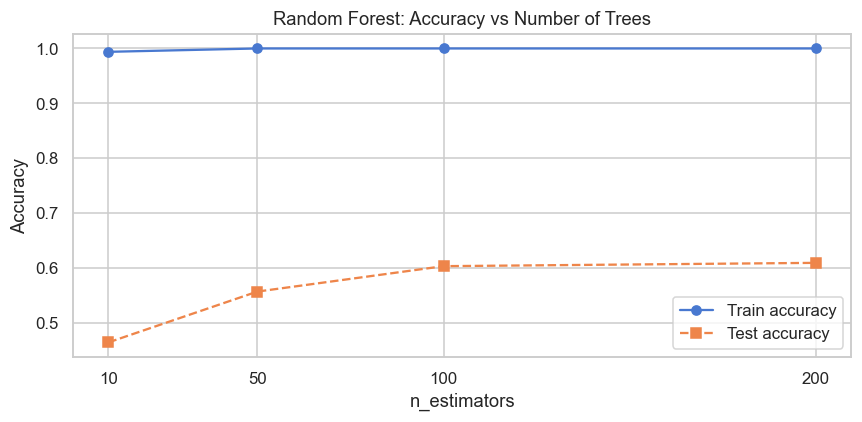


Random Forest (n=200)  accuracy : 0.6089
Random Forest (n=200)  macro F1 : 0.5789


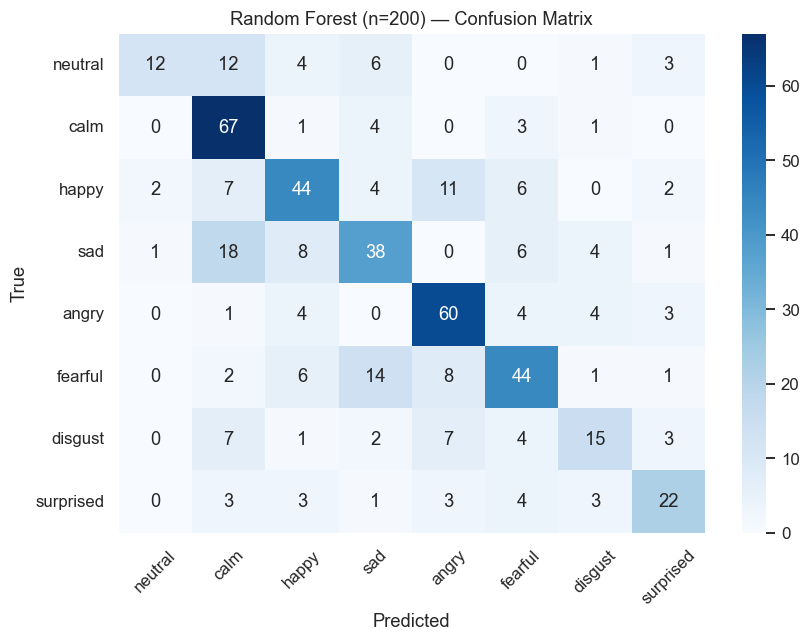

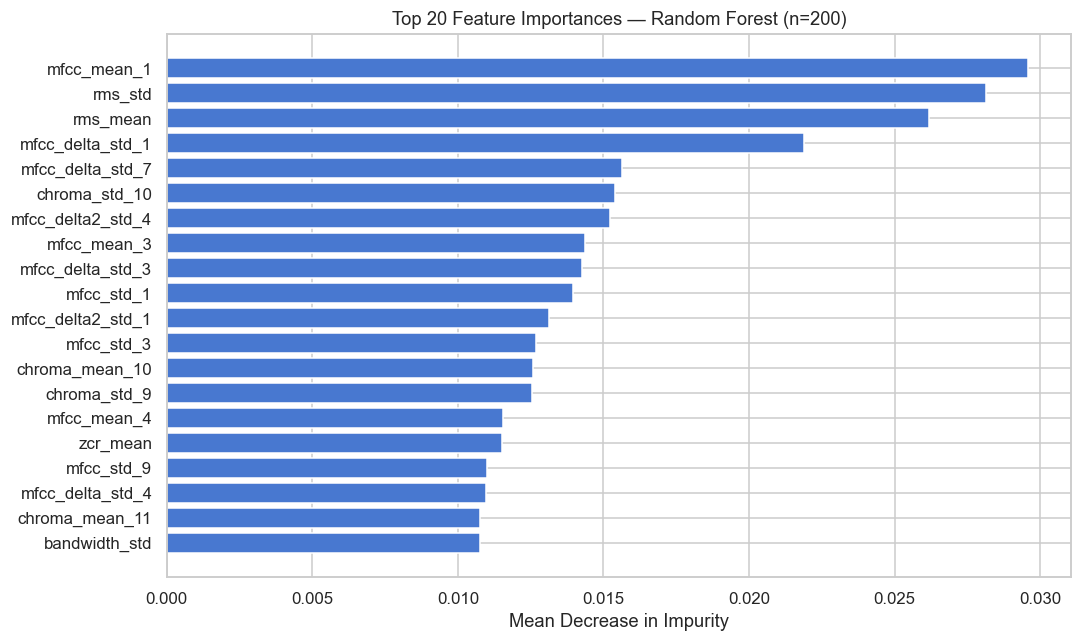

In [4]:
n_estimators_list = [10, 50, 100, 200]
rf_train_accs, rf_test_accs = [], []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_train_accs.append(accuracy(y_train, rf.predict(X_train)))
    rf_test_accs.append(accuracy(y_test,  rf.predict(X_test)))
    print(f'n_estimators={n:<4}  train={rf_train_accs[-1]:.4f}  test={rf_test_accs[-1]:.4f}')

# ── Accuracy vs n_estimators ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimators_list, rf_train_accs, 'o-',  label='Train accuracy')
ax.plot(n_estimators_list, rf_test_accs,  's--', label='Test accuracy')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Accuracy')
ax.set_title('Random Forest: Accuracy vs Number of Trees')
ax.set_xticks(n_estimators_list); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_n_estimators.png'), bbox_inches='tight')
plt.show()

# ── Final evaluation at n=200 ────────────────────────────────────────────────
rf_best = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)

print(f'\nRandom Forest (n=200)  accuracy : {accuracy(y_test, y_pred_rf):.4f}')
print(f'Random Forest (n=200)  macro F1 : {f1_score(y_test, y_pred_rf, average="macro"):.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion(confusion_matrix(y_test, y_pred_rf),
               'Random Forest (n=200) — Confusion Matrix', ax, emotion_labels)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_random_forest.png'), bbox_inches='tight')
plt.show()

# ── RF feature importances (top 20) ─────────────────────────────────────────
rf_imp    = rf_best.feature_importances_
rf_top    = np.argsort(rf_imp)[::-1][:20]
fig, ax   = plt.subplots(figsize=(10, 6))
ax.barh([feature_names[i] for i in rf_top[::-1]], rf_imp[rf_top[::-1]])
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Top 20 Feature Importances — Random Forest (n=200)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_feature_importances.png'), bbox_inches='tight')
plt.show()

## 4. AdaBoost

AdaBoost (stumps, n=200)  accuracy : 0.4052
AdaBoost (stumps, n=200)  macro F1 : 0.3728


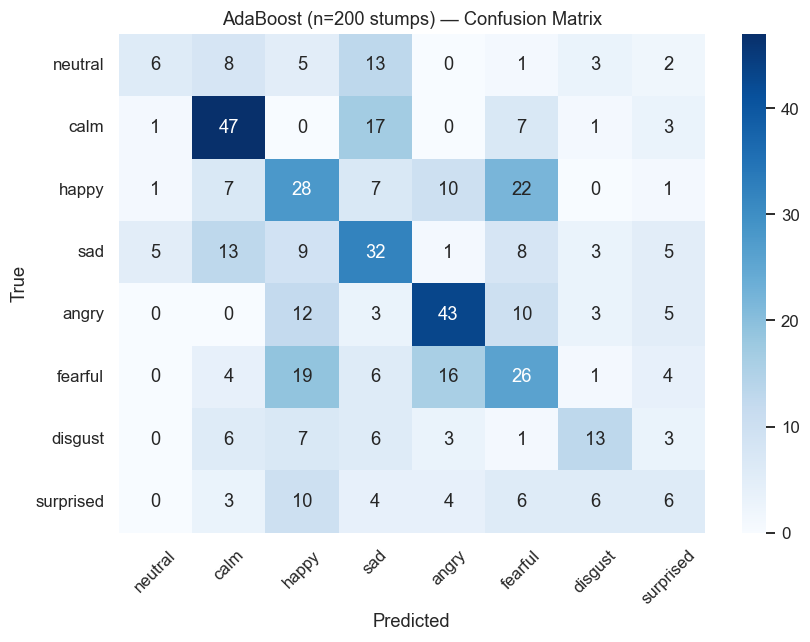


=== Model Comparison ===
                         Accuracy  Macro-F1
Model                                      
MiniLearn DT  (depth=6)    0.4032    0.3779
sklearn  DT   (depth=5)    0.3952    0.3821
sklearn  DT   (depth=4)    0.3690    0.3032
Random Forest (n=200)      0.6089    0.5789
AdaBoost      (n=200)      0.4052    0.3728


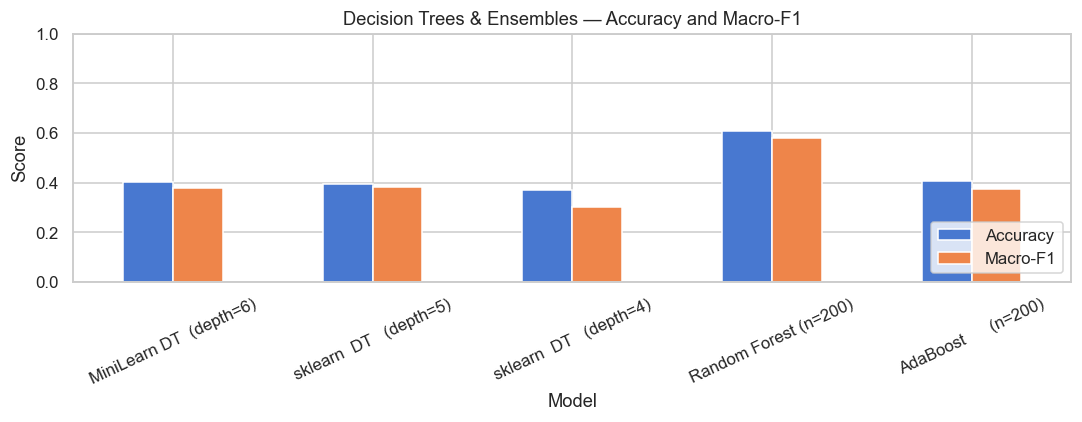

In [5]:
# AdaBoost with decision stumps (max_depth=1) — standard configuration
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200, learning_rate=0.5, random_state=42
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print(f'AdaBoost (stumps, n=200)  accuracy : {accuracy(y_test, y_pred_ada):.4f}')
print(f'AdaBoost (stumps, n=200)  macro F1 : {f1_score(y_test, y_pred_ada, average="macro"):.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion(confusion_matrix(y_test, y_pred_ada),
               'AdaBoost (n=200 stumps) — Confusion Matrix', ax, emotion_labels)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_adaboost.png'), bbox_inches='tight')
plt.show()

# ── Summary comparison table ─────────────────────────────────────────────────
best_depth_sk = depths[int(np.argmax(sk_test_accs))]
sk_dt_best = DecisionTreeClassifier(max_depth=best_depth_sk, random_state=42)
sk_dt_best.fit(X_train, y_train)
y_pred_sk_dt_best = sk_dt_best.predict(X_test)

ml_dt_final = DecisionTree(max_depth=best_depth_ml, criterion='gini')
ml_dt_final.fit(X_train, y_train)
y_pred_ml_dt_final = ml_dt_final.predict(X_test)

summary_rows = [
    ('MiniLearn DT  (depth={})'.format(best_depth_ml), y_pred_ml_dt_final),
    ('sklearn  DT   (depth={})'.format(best_depth_sk), y_pred_sk_dt_best),
    ('sklearn  DT   (depth=4)',                         y_pred_sk_dt),
    ('Random Forest (n=200)',                           y_pred_rf),
    ('AdaBoost      (n=200)',                           y_pred_ada),
]

table = pd.DataFrame([
    {
        'Model':    label,
        'Accuracy': round(accuracy(y_test, yp), 4),
        'Macro-F1': round(f1_score(y_test, yp, average='macro'), 4),
    }
    for label, yp in summary_rows
]).set_index('Model')

print('\n=== Model Comparison ===')
print(table.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
table.plot(kind='bar', ax=ax, rot=25)
ax.set_title('Decision Trees & Ensembles — Accuracy and Macro-F1')
ax.set_ylabel('Score'); ax.set_ylim(0, 1); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tree_ensemble_comparison.png'), bbox_inches='tight')
plt.show()

## 5. Discussion

*Address:*
- *At what max_depth does the single decision tree start to overfit?*
- *How much does Random Forest improve over a single tree?  Why?*
- *Which features are most important according to the RF feature importances?*